In [31]:
# install necessary packages
!pip install wbgapi
!pip install scikit-learn
!pip install pandas
!pip install xgboost
!pip install statsmodels
!pip install lxml
!pip install matplotlib

In [32]:
# import necessary libraries
import pandas as pd
import numpy as np
import requests
import wbgapi as wb
import matplotlib.pyplot as plt
from io import StringIO
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RepeatedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [33]:
df_defaults = pd.read_csv('sovereign_default_database.csv')

codes_df = pd.read_csv('country_codes.csv')

df_defaults.head()

,k,DEBT_COUNTRY,DEBT_COUNTRY_GROUP,DEBT_YEAR,DEBT_TOTAL_2025,DEBT_IMF_2025,DEBT_IBRD_2025,DEBT_IDA_2025,DEBT_IADB_2025,DEBT_PARIS_CLUB_2025,...,DEBT_LC_DEBT_DEF_SOVEREIGNS_2025,DEBT_ARREARS_TOTAL_SOVEREIGNS_2025,DEBT_ARREARS_DEFRATE_CONV_DEF_2025,DEBT_ARREARS_DEFRATE_SOVEREIGNS_2025,DEBT_ARREARS_DEFRATE_WORLD_GDP_2025,DEBT_PARIS_CLUB_DEBT_2025,DEBT_GROSS_CHINA_2025,DEBT_GROSS_WORLD_PUBLIC_DEBT_2025,DEBT_GROSS_EME_OTHER_GDP_2025,DEBT_GROSS_WORLD_PRODUCT_2025
0,WORLD_1960,World,World,1960,13353.27,173.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1365.0
1,WORLD_1961,World,World,1961,15269.62,53.0,0.0,0.0,0.0,300.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1420.0
2,WORLD_1962,World,World,1962,14661.35,54.0,0.0,0.0,0.0,270.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1525.0
3,WORLD_1963,World,World,1963,15053.83,25.3,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1638.0
4,WORLD_1964,World,World,1964,16915.69,211.0,0.0,0.0,0.0,270.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1800.0


In [34]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_credit_rating"

# Define headers to mimic a browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers=headers)
tables = pd.read_html(StringIO(response.text))
s_and_p_df = tables[0]

print(f"# of countries: {len(s_and_p_df)}")
print(s_and_p_df.head())

# of countries: 141
  Country/Territory Rating Outlook              Date Ref.
0           Albania     BB  Stable     21 March 2025  [3]
1           Andorra     A−  Stable       10 May 2024  [4]
2            Angola     B−  Stable   4 February 2022  [5]
3         Argentina   CCC+  Stable  17 December 2025  [6]
4           Armenia    BB−  Stable    25 August 2023  [7]


In [35]:
def clean_country_name(series):
    return (series.astype(str)
            .str.strip()
            .str.replace(r'\[.*?\]', '', regex=True)
            .str.lower())

s_and_p_df['country_key'] = clean_country_name(s_and_p_df['Country/Territory'])
codes_df['country_key'] = clean_country_name(codes_df['Country'])

merged_df = pd.merge(
    s_and_p_df,
    codes_df[['country_key', 'country_code']],
    on='country_key',
    how='left',
    indicator=True
)

# Check for non-matching countries
unmatched = merged_df[merged_df['_merge'] == 'left_only']
if not unmatched.empty:
    print(f"Warning: The following {len(unmatched)} countries did not match:")
    print(unmatched['Country/Territory'].unique())

ratings_df = merged_df.drop(columns=['country_key', '_merge', 'Ref.'])

['Bahamas' 'Bolivia' 'Cook Islands' 'Curacao'
 'Democratic Republic of the Congo' 'Dominican Republic'
 'Falkland Islands' 'Laos' 'Moldova' 'Netherlands' 'North Macedonia'
 'Philippines' 'Republic of the Congo' 'Saint Helena' 'South Korea'
 'Taiwan' 'Turks and Caicos Islands' 'United Arab Emirates'
 'United Kingdom' 'United States' 'Vietnam']


In [36]:
iso_mapping = {
    'bahamas': 'BHS',
    'bolivia': 'BOL',
    'cook islands': 'COK',
    'curacao': 'CUW',
    'democratic republic of the congo': 'COD',
    'dominican republic': 'DOM',
    'falkland islands': 'FLK',
    'laos': 'LAO',
    'moldova': 'MDA',
    'netherlands': 'NLD',
    'north macedonia': 'MKD',
    'philippines': 'PHL',
    'republic of the congo': 'COG',
    'saint helena': 'SHN',
    'south korea': 'KOR',
    'taiwan': 'TWN',
    'turks and caicos islands': 'TCA',
    'united arab emirates': 'ARE',
    'united kingdom': 'GBR',
    'united states': 'USA',
    'vietnam': 'VNM'
}
ratings_df['country_code'] = ratings_df['country_code'].fillna(
    ratings_df['Country/Territory'].str.lower().map(iso_mapping)
)

still_missing = ratings_df[ratings_df['country_code'].isna()]
if not still_missing.empty:
    print(f"Still missing codes for: {still_missing['Country/Territory'].unique()}")
else:
    print("All country codes successfully mapped!")

ratings_df.head()


All country codes successfully mapped!


,Country/Territory,Rating,Outlook,Date,country_code
0,Albania,BB,Stable,21 March 2025,ALB
1,Andorra,A−,Stable,10 May 2024,AND
2,Angola,B−,Stable,4 February 2022,AGO
3,Argentina,CCC+,Stable,17 December 2025,ARG
4,Armenia,BB−,Stable,25 August 2023,ARM


In [37]:
df_defaults

,k,DEBT_COUNTRY,DEBT_COUNTRY_GROUP,DEBT_YEAR,DEBT_TOTAL_2025,DEBT_IMF_2025,DEBT_IBRD_2025,DEBT_IDA_2025,DEBT_IADB_2025,DEBT_PARIS_CLUB_2025,...,DEBT_LC_DEBT_DEF_SOVEREIGNS_2025,DEBT_ARREARS_TOTAL_SOVEREIGNS_2025,DEBT_ARREARS_DEFRATE_CONV_DEF_2025,DEBT_ARREARS_DEFRATE_SOVEREIGNS_2025,DEBT_ARREARS_DEFRATE_WORLD_GDP_2025,DEBT_PARIS_CLUB_DEBT_2025,DEBT_GROSS_CHINA_2025,DEBT_GROSS_WORLD_PUBLIC_DEBT_2025,DEBT_GROSS_EME_OTHER_GDP_2025,DEBT_GROSS_WORLD_PRODUCT_2025
0,WORLD_1960,World,World,1960,13353.27,173.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1365.0
1,WORLD_1961,World,World,1961,15269.62,53.0,0.0,0.0,0.0,300.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1420.0
2,WORLD_1962,World,World,1962,14661.35,54.0,0.0,0.0,0.0,270.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1525.0
3,WORLD_1963,World,World,1963,15053.83,25.3,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1638.0
4,WORLD_1964,World,World,1964,16915.69,211.0,0.0,0.0,0.0,270.0,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1800.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10849,ZWE_2020,Zimbabwe,Other developing countries,2020,8349.00,0.0,1015.0,361.0,NaN,2067.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10850,ZWE_2021,Zimbabwe,Other developing countries,2021,8377.00,0.0,1042.0,377.0,NaN,1905.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10851,ZWE_2022,Zimbabwe,Other developing countries,2022,8332.00,0.0,1074.0,381.0,NaN,1822.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10852,ZWE_2023,Zimbabwe,Other developing countries,2023,8485.00,0.0,1100.0,407.0,NaN,1826.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df_defaults['country_key'] = clean_country_name(df_defaults['DEBT_COUNTRY'])
defaults_with_codes = pd.merge(df_defaults, codes_df[['country_key', 'country_code']], on='country_key', how='left')

recent_defaults = defaults_with_codes[defaults_with_codes['DEBT_YEAR'].between(2021, 2024)]

default_features = recent_defaults.groupby('country_code').agg(
    # Average debt over the last 4 years
    avg_sovereign_debt_4yr=('DEBT_TOTAL_2025', 'mean'),
).reset_index()

default_features.head()

,country_code,avg_sovereign_debt_4yr
0,ABW,NaN
1,AFG,2095.8725
2,AGO,1404.0050
3,ALB,0.0000
4,ARG,13272.6625


In [39]:
indicators = {
    'FP.CPI.TOTL.ZG': 'inflation', # Inflation, consumer prices (%)
}
years = range(2022, 2025)

wb_df = wb.data.DataFrame(list(indicators.keys()), time=years, skipAggs=True)

wb_df = wb_df.reset_index()
wb_df = wb_df.rename(columns={
    'economy': 'country_code',
    'YR2022': 'inflation_2022',
    'YR2023': 'inflation_2023',
    'YR2024': 'inflation_2024'
})
wb_df

,country_code,inflation_2022,inflation_2023,inflation_2024
0,ABW,NaN,NaN,NaN
1,AFG,13.712102,-4.644709,-6.601186
2,AGO,21.355290,13.644102,28.240495
3,ALB,6.725203,4.758346,2.215874
4,AND,NaN,NaN,NaN
...,...,...,...,...
212,XKX,11.580510,4.944324,1.619450
213,YEM,NaN,NaN,NaN
214,ZAF,7.039873,6.075244,4.361152
215,ZMB,10.993204,10.884532,14.985626


In [40]:
def get_imf_data(indicator_id, years):
    base_url = f"https://www.imf.org/external/datamapper/api/v1/{indicator_id}"
    params = {'periods': ','.join(map(str, years))}

    response = requests.get(base_url, params=params)
    data = response.json().get('values', {}).get(indicator_id, {})

    rows = []
    for country, years_data in data.items():
        for year, value in years_data.items():
            rows.append({'country_code': country, 'year': int(year), indicator_id: value})

    return pd.DataFrame(rows)

indicator_map = {
    'GGXCNL_NGDP': 'fiscal_balance',      # Budget surplus/deficit (% of GDP)
    'BCA_NGDPD':   'current_account',     # Net trade & investment income (% of GDP)
    'NGDP_RPCH':    'gdp_growth',          # Real economic growth (annual %)
    'LUR':          'unemployment_rate',   # Labor market slack/social risk (%)
    'GGXWDG_NGDP':  'gov_debt_gdp',        # Total public debt load (% of GDP)
    'RAX_USD':      'total_reserves',      # FX liquidity (Millions of USD)
    'PPPPC':        'gdp_per_capita_ppp',  # Living standards/tax base (PPP)
    'NX_PNGDP':     'net_exports_gdp'      # Trade balance (% of GDP)
}

imf_indicators = list(indicator_map.keys())
years = range(2022, 2026)

# Fetch data from IMF DataMapper
all_dfs = []
for ind in imf_indicators:
    print(f"Fetching {ind} ({indicator_map[ind]})...")
    df = get_imf_data(ind, years)

    if not df.empty:
        df = df.rename(columns={ind: indicator_map[ind]})
        all_dfs.append(df)

if all_dfs:
    imf_master = all_dfs[0]
    for next_df in all_dfs[1:]:
        imf_master = pd.merge(imf_master, next_df, on=['country_code', 'year'], how='outer')

imf_master.head()

Fetching GGXCNL_NGDP (fiscal_balance)...
Fetching BCA_NGDPD (current_account)...
Fetching NGDP_RPCH (gdp_growth)...
Fetching LUR (unemployment_rate)...
Fetching GGXWDG_NGDP (gov_debt_gdp)...
Fetching RAX_USD (total_reserves)...
Fetching PPPPC (gdp_per_capita_ppp)...
Fetching NX_PNGDP (net_exports_gdp)...


,country_code,year,fiscal_balance,current_account,gdp_growth,unemployment_rate,gov_debt_gdp,gdp_per_capita_ppp
0,ABW,1986,NaN,NaN,NaN,19.6,NaN,8114.188
1,ABW,1987,NaN,NaN,16.1,14.5,NaN,9229.281
2,ABW,1988,NaN,NaN,18.6,5.0,NaN,10969.003
3,ABW,1989,NaN,NaN,12.1,1.5,NaN,12568.694
4,ABW,1990,NaN,NaN,4.0,1.3,NaN,13414.113


In [41]:
indicator_cols = [col for col in imf_master.columns if col not in ['country_code', 'year']]

# Group by country_code and calculate the mean for each indicator (for 2022-2025)
imf_df = imf_master.groupby('country_code')[indicator_cols].mean().reset_index()

imf_df.head()

,country_code,fiscal_balance,current_account,gdp_growth,unemployment_rate,gov_debt_gdp,gdp_per_capita_ppp
0,ABW,-2.016216,0.990909,3.588889,6.941304,60.410811,32406.600435
1,ADVEC,-4.229032,-0.163462,2.271154,6.321154,96.361290,40598.434231
2,AFG,-0.950000,12.695833,4.204348,NaN,53.220833,1953.057208
3,AFQ,-2.962500,-1.090385,3.863415,NaN,49.231250,4539.835212
4,AGO,-0.944444,0.951923,4.680769,NaN,55.996875,5920.567885


In [42]:
ml_df = pd.merge(wb_df, imf_df, on='country_code', how='outer')
ml_df = pd.merge(ratings_df, ml_df, on='country_code', how='outer')
ml_df = pd.merge(ml_df, default_features, on='country_code', how='left')
ml_df["avg_sovereign_debt_4yr"] = ml_df["avg_sovereign_debt_4yr"].fillna(0) # Countries not in that dataset did not have foreign debt
ml_df.head()

,Country/Territory,Rating,Outlook,Date,country_code,inflation_2022,inflation_2023,inflation_2024,fiscal_balance,current_account,gdp_growth,unemployment_rate,gov_debt_gdp,gdp_per_capita_ppp,avg_sovereign_debt_4yr
0,Aruba,BBB+,Stable,24 March 2025,ABW,NaN,NaN,NaN,-2.016216,0.990909,3.588889,6.941304,60.410811,32406.600435,0.0000
1,NaN,NaN,NaN,NaN,ADVEC,NaN,NaN,NaN,-4.229032,-0.163462,2.271154,6.321154,96.361290,40598.434231,0.0000
2,NaN,NaN,NaN,NaN,AFG,13.712102,-4.644709,-6.601186,-0.950000,12.695833,4.204348,NaN,53.220833,1953.057208,2095.8725
3,NaN,NaN,NaN,NaN,AFQ,NaN,NaN,NaN,-2.962500,-1.090385,3.863415,NaN,49.231250,4539.835212,0.0000
4,Angola,B−,Stable,4 February 2022,AGO,21.355290,13.644102,28.240495,-0.944444,0.951923,4.680769,NaN,55.996875,5920.567885,1404.0050


In [43]:
# Filter for countries without a rating
no_rating = ml_df[ml_df['Rating'].isna()]
yes_rating = ml_df[~ml_df['Rating'].isna()]

print(f"Number of countries/entities without a rating: {len(no_rating)}")
print(no_rating['country_code'].unique())

print(f"Number of countries/entities with a rating: {len(yes_rating)}")
print(no_rating['country_code'].unique())

ml_df = ml_df.dropna(subset=['Rating'])

Number of countries/entities without a rating: 117
['ADVEC' 'AFG' 'AFQ' 'APQ' 'AS5' 'ASM' 'ATG' 'AZQ' 'BDI' 'BLR' 'BRN' 'BTN'
 'CAF' 'CAQ' 'CBQ' 'CHI' 'CMQ' 'COM' 'CUB' 'CYM' 'DA' 'DJI' 'DMA' 'DZA'
 'EAQ' 'EDE' 'EEQ' 'ERI' 'EU' 'EUQ' 'EURO' 'FRO' 'FSM' 'GAB' 'GIB' 'GMB'
 'GNB' 'GNQ' 'GRD' 'GRL' 'GUM' 'GUY' 'HTI' 'IMN' 'IRN' 'KHM' 'KIR' 'KNA'
 'LBR' 'LBY' 'LCA' 'LSO' 'MAC' 'MAE' 'MAF' 'MCO' 'MDV' 'MECA' 'MEQ' 'MHL'
 'MLI' 'MMR' 'MNP' 'MRT' 'MWI' 'NAM' 'NAQ' 'NCL' 'NER' 'NMQ' 'NPL' 'NRU'
 'OAE' 'OEMDC' 'PIQ' 'PLW' 'PRI' 'PRK' 'PSE' 'PYF' 'RUS' 'SAQ' 'SDN' 'SEQ'
 'SLB' 'SLE' 'SMQ' 'SOM' 'SSA' 'SSD' 'SSQ' 'STP' 'SWZ' 'SXM' 'SYC' 'SYR'
 'TKM' 'TLS' 'TON' 'TUN' 'TUV' 'TZA' 'UVK' 'VCT' 'VEN' 'VGB' 'VIR' 'VUT'
 'WBG' 'WE' 'WEOWORLD' 'WEQ' 'WHQ' 'WSM' 'XKX' 'YEM' 'ZWE']
Number of countries/entities with a rating: 141
['ADVEC' 'AFG' 'AFQ' 'APQ' 'AS5' 'ASM' 'ATG' 'AZQ' 'BDI' 'BLR' 'BRN' 'BTN'
 'CAF' 'CAQ' 'CBQ' 'CHI' 'CMQ' 'COM' 'CUB' 'CYM' 'DA' 'DJI' 'DMA' 'DZA'
 'EAQ' 'EDE' 'EEQ' 'ERI' 'EU' 'EU

In [44]:
ml_df

,Country/Territory,Rating,Outlook,Date,country_code,inflation_2022,inflation_2023,inflation_2024,fiscal_balance,current_account,gdp_growth,unemployment_rate,gov_debt_gdp,gdp_per_capita_ppp,avg_sovereign_debt_4yr
0,Aruba,BBB+,Stable,24 March 2025,ABW,NaN,NaN,NaN,-2.016216,0.990909,3.588889,6.941304,60.410811,32406.600435,0.0000
4,Angola,B−,Stable,4 February 2022,AGO,21.355290,13.644102,28.240495,-0.944444,0.951923,4.680769,NaN,55.996875,5920.567885,1404.0050
5,Albania,BB,Stable,21 March 2025,ALB,6.725203,4.758346,2.215874,-4.188571,-5.815385,2.978846,11.809615,61.560000,10200.101904,0.0000
6,Andorra,A−,Stable,10 May 2024,AND,NaN,NaN,NaN,1.132258,15.600000,1.887097,2.618182,30.722581,62698.777136,0.0000
8,United Arab Emirates,AA,Stable,2 July 2007,ARE,5.291226,1.626708,1.663365,4.336585,10.173077,3.719231,NaN,19.030303,69430.806712,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,United States,AA+,Stable,5 August 2011,USA,8.002800,4.116338,2.949525,-6.422581,-2.748077,2.561538,5.801923,102.638710,48889.801327,0.0000
240,Uzbekistan,BB,Stable,21 November 2025,UZB,11.446644,9.956591,9.628255,-0.987500,-0.405000,5.082500,5.450000,20.020000,6997.127800,15.4000
245,Vietnam,BB+,Stable,26 May 2022,VNM,3.156507,3.252893,3.621093,-1.958824,-0.940385,6.332692,4.438095,34.293750,7248.468365,0.0000
255,South Africa,BB,Positive,14 November 2025,ZAF,7.039873,6.075244,4.361152,-3.503125,-1.009615,1.967308,23.982692,51.890625,10703.527904,0.0000


In [45]:
ml_df.shape

(141, 15)

In [46]:
ml_df.columns

Index(['Country/Territory', 'Rating', 'Outlook', 'Date', 'country_code',
       'inflation_2022', 'inflation_2023', 'inflation_2024', 'fiscal_balance',
       'current_account', 'gdp_growth', 'unemployment_rate', 'gov_debt_gdp',
       'gdp_per_capita_ppp', 'avg_sovereign_debt_4yr'],
      dtype='object')

In [47]:
ml_df = ml_df.reset_index()

#preparing for training
ml_df['Rating'] = (
    ml_df['Rating']
    .str.strip()
    .str.replace('−', '-', regex=False)   # fix Unicode minus
)

#-mapping credit rating to a numerical value for regression
credit_rating_order = ['SD', 'CCC-', 'CCC+', 'B-', 'B', 'B+', 'BB-', 'BB', 'BB+', 'BBB-','BBB', 'BBB+',
                       'A-', 'A', 'A+', 'AA-', 'AA', 'AA+', 'AAA']
rating_map = {r:i for i, r in enumerate(credit_rating_order)}
ml_df['Rating'] = ml_df['Rating'].map(rating_map)

#-one hot outlook column
outlook_encoder = OneHotEncoder()
outlook_encoded = outlook_encoder.fit_transform(ml_df[['Outlook']])
encoded_outlook_df = pd.DataFrame(outlook_encoded.toarray(), columns=outlook_encoder.get_feature_names_out(['Outlook']))
ml_df = ml_df.drop(columns=['Outlook']).join(encoded_outlook_df)

In [48]:
ml_df

,index,Country/Territory,Rating,Date,country_code,inflation_2022,inflation_2023,inflation_2024,fiscal_balance,current_account,gdp_growth,unemployment_rate,gov_debt_gdp,gdp_per_capita_ppp,avg_sovereign_debt_4yr,Outlook_Negative,Outlook_Positive,Outlook_Stable,Outlook_nan
0,0,Aruba,11,24 March 2025,ABW,NaN,NaN,NaN,-2.016216,0.990909,3.588889,6.941304,60.410811,32406.600435,0.0000,0.0,0.0,1.0,0.0
1,4,Angola,3,4 February 2022,AGO,21.355290,13.644102,28.240495,-0.944444,0.951923,4.680769,NaN,55.996875,5920.567885,1404.0050,0.0,0.0,1.0,0.0
2,5,Albania,7,21 March 2025,ALB,6.725203,4.758346,2.215874,-4.188571,-5.815385,2.978846,11.809615,61.560000,10200.101904,0.0000,0.0,0.0,1.0,0.0
3,6,Andorra,12,10 May 2024,AND,NaN,NaN,NaN,1.132258,15.600000,1.887097,2.618182,30.722581,62698.777136,0.0000,0.0,0.0,1.0,0.0
4,8,United Arab Emirates,16,2 July 2007,ARE,5.291226,1.626708,1.663365,4.336585,10.173077,3.719231,NaN,19.030303,69430.806712,0.0000,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,238,United States,17,5 August 2011,USA,8.002800,4.116338,2.949525,-6.422581,-2.748077,2.561538,5.801923,102.638710,48889.801327,0.0000,0.0,0.0,1.0,0.0
137,240,Uzbekistan,7,21 November 2025,UZB,11.446644,9.956591,9.628255,-0.987500,-0.405000,5.082500,5.450000,20.020000,6997.127800,15.4000,0.0,0.0,1.0,0.0
138,245,Vietnam,8,26 May 2022,VNM,3.156507,3.252893,3.621093,-1.958824,-0.940385,6.332692,4.438095,34.293750,7248.468365,0.0000,0.0,0.0,1.0,0.0
139,255,South Africa,7,14 November 2025,ZAF,7.039873,6.075244,4.361152,-3.503125,-1.009615,1.967308,23.982692,51.890625,10703.527904,0.0000,0.0,1.0,0.0,0.0


# BASELINE METHOD: ORDERED LOGIT


In [49]:
# split ml_df into the pieces ordered logit needs
def get_ol_features_target(df): # return (X, y, countries) and drops the same identifiers the ML models drop
    drop_cols = ['Country/Territory', 'Date', 'country_code', 'Rating', 'index']
    X = df.drop(columns=drop_cols).copy()
    y = df['Rating'].values
    countries = df['Country/Territory'].values
    return X, y, countries

def drop_reference_outlook(X): # drop one Outlook dummy so it is not collinear with the model thresholds
    outlook_cols = [c for c in X.columns if c.startswith('Outlook_')]
    if outlook_cols:
        X = X.drop(columns=[outlook_cols[0]])
    return X

In [50]:
# per-fold preprocessing, fit on train, apply to val

def impute_with_train_means(X_tr, X_va): # fill NaNs with training-column means, apply same means to validation
    means = X_tr.mean()
    return X_tr.fillna(means), X_va.fillna(means)

def standardize_with_train_stats(X_tr, X_va): # z-score features using training mean/sd; replace 0 sd with 1 to avoid div-by-zero
    mu = X_tr.mean()
    sd = X_tr.std().replace(0, 1)
    return (X_tr - mu) / sd, (X_va - mu) / sd

In [51]:
# fit the proportional-odds model and turn probabilities into an expected rating
def fit_proportional_odds(X_tr, y_tr): # estimate ordered logit via MLE, BFGS is robust for modest feature counts
    model = OrderedModel(y_tr, X_tr, distr='logit')
    return model.fit(method='bfgs', disp=False, maxiter=1000)

def expected_rating(result, X_va, y_tr): # predicted rating = sum over classes of P(class) * class_value (comparable to RF/XGB)
    probs = np.asarray(result.predict(X_va))
    classes = np.sort(np.unique(y_tr)).astype(float)
    return probs @ classes

In [52]:
# assemble results and run one CV fold

def assemble_fold_df(fold, countries_va, y_va, preds): # package one fold's predictions into the same columns the RF/XGB functions produce.
    return pd.DataFrame({
        'fold': fold, 'country': countries_va,
        'true_rating': y_va, 'pred_rating': preds,
        'error': np.abs(y_va - preds)
    })

def run_ordered_logit_fold(fold, X, y, countries, tr, va): # impute standardize fit predict and record results for a single CV fold
    print(f"training for fold: {fold}")
    X_tr, X_va = impute_with_train_means(X.iloc[tr], X.iloc[va])
    X_tr, X_va = standardize_with_train_stats(X_tr, X_va)
    result = fit_proportional_odds(X_tr, y[tr])
    preds = expected_rating(result, X_va, y[tr])
    return assemble_fold_df(fold, countries[va], y[va], preds)

In [53]:
# repeated k-fold CV same splits as the ML models

def ordered_logit_model(credit_rating_df): # ordered logit baseline with 5x5 repeated k-fold
    X, y, countries = get_ol_features_target(credit_rating_df)
    X = drop_reference_outlook(X)
    rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
    folds = [run_ordered_logit_fold(f, X, y, countries, tr, va)
             for f, (tr, va) in enumerate(rkf.split(X))]
    return pd.concat(folds, ignore_index=True)

In [54]:
# run the ordered logit baseline
ordered_logit = ordered_logit_model(ml_df.copy())
ordered_logit.head()

training for fold: 0
training for fold: 1
training for fold: 2
training for fold: 3


/srv/conda/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


training for fold: 4
training for fold: 5
training for fold: 6
training for fold: 7
training for fold: 8
training for fold: 9
training for fold: 10
training for fold: 11
training for fold: 12
training for fold: 13
training for fold: 14
training for fold: 15
training for fold: 16
training for fold: 17


/srv/conda/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


training for fold: 18
training for fold: 19
training for fold: 20
training for fold: 21
training for fold: 22
training for fold: 23
training for fold: 24


,fold,country,true_rating,pred_rating,error
0,0,United Arab Emirates,16,17.977510,1.977510
1,0,Benin,6,5.666739,0.333261
2,0,Burkina Faso,2,5.379851,3.379851
3,0,Bermuda,14,9.658669,4.341331
4,0,Chile,13,9.138427,3.861573


# RANDOM FOREST

In [55]:
def random_forest_model(credit_rating_df):

  # --- keep identifiers separately ---
  countries = credit_rating_df['Country/Territory'].values

  # --- features / target ---
  drop_columns = ['Country/Territory', 'Date', 'country_code', 'Rating']
  X = credit_rating_df.drop(columns=drop_columns)
  y = credit_rating_df['Rating'].values   # numeric already

  # --- model ---
  model = RandomForestRegressor(
      n_estimators=200,
      max_depth=3,
      min_samples_leaf=10,
      max_features="sqrt",
      random_state=42
  )

  # --- CV ---
  rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

  # --- collect results ---
  all_predictions = []

  for fold, (train_idx, val_idx) in enumerate(rkf.split(X)):
    print(f"training for fold: {fold}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    # store row-by-row results
    fold_df = pd.DataFrame({
        'fold': fold,
        'country': countries[val_idx],
        'true_rating': y_val,
        'pred_rating': preds,
        'error': abs(y_val - preds)
    })

    all_predictions.append(fold_df)

  return pd.concat(all_predictions, ignore_index=True)

random_forest = random_forest_model(ml_df.copy())

training for fold: 0
training for fold: 1
training for fold: 2
training for fold: 3
training for fold: 4
training for fold: 5
training for fold: 6
training for fold: 7
training for fold: 8
training for fold: 9
training for fold: 10
training for fold: 11
training for fold: 12
training for fold: 13
training for fold: 14
training for fold: 15
training for fold: 16
training for fold: 17
training for fold: 18
training for fold: 19
training for fold: 20
training for fold: 21
training for fold: 22
training for fold: 23
training for fold: 24


In [56]:
random_forest.head()

,fold,country,true_rating,pred_rating,error
0,0,United Arab Emirates,16,13.103680,2.896320
1,0,Benin,6,7.573104,1.573104
2,0,Burkina Faso,2,5.146162,3.146162
3,0,Bermuda,14,10.815786,3.184214
4,0,Chile,13,8.412163,4.587837


# GRADIENT BOOSTING

In [57]:
def gradient_tree_model(credit_rating_df):

  # --- keep identifiers separately ---
  countries = credit_rating_df['Country/Territory'].values

  # --- features / target ---
  drop_columns = ['Country/Territory', 'Date', 'country_code', 'Rating']
  X = credit_rating_df.drop(columns=drop_columns)
  y = credit_rating_df['Rating'].values   # numeric already

  # --- CV ---
  rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

  # --- collect results ---
  all_predictions = []

  for fold, (train_idx, val_idx) in enumerate(rkf.split(X)):
    print(f"training for fold: {fold}")
    # --- model ---
    model = XGBRegressor(
        objective='reg:squarederror',
        min_child_weight=5,
        n_estimators=500,
        learning_rate=0.03,
        max_depth=2,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=20,
        reg_lambda=1.0,
        reg_alpha=.1
    )

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)

    # store row-by-row results
    fold_df = pd.DataFrame({
        'fold': fold,
        'country': countries[val_idx],
        'true_rating': y_val,
        'pred_rating': preds,
        'error': abs(y_val - preds)
    })

    all_predictions.append(fold_df)

  return pd.concat(all_predictions, ignore_index=True)

gradient_tree = gradient_tree_model(ml_df.copy())

training for fold: 0
training for fold: 1
training for fold: 2
training for fold: 3
training for fold: 4
training for fold: 5
training for fold: 6
training for fold: 7
training for fold: 8
training for fold: 9
training for fold: 10
training for fold: 11
training for fold: 12
training for fold: 13
training for fold: 14
training for fold: 15
training for fold: 16
training for fold: 17
training for fold: 18
training for fold: 19
training for fold: 20
training for fold: 21
training for fold: 22
training for fold: 23
training for fold: 24


In [58]:
gradient_tree

,fold,country,true_rating,pred_rating,error
0,0,United Arab Emirates,16,14.378483,1.621517
1,0,Benin,6,6.844629,0.844629
2,0,Burkina Faso,2,4.925044,2.925044
3,0,Bermuda,14,10.704511,3.295489
4,0,Chile,13,8.007627,4.992373
...,...,...,...,...,...
700,24,Suriname,2,3.701751,1.701751
701,24,Sweden,18,16.862955,1.137045
702,24,Togo,5,5.007523,0.007523
703,24,Thailand,11,7.365900,3.634100


# Gradient Boosting vs Random Forest Performance

In [59]:
num_to_rating = {i:r for i, r in enumerate(credit_rating_order)}
#decision boundary(rounding) to map back to pred rating

#-get credit rating
random_forest['credit_rating'] = random_forest['true_rating'].map(num_to_rating)
gradient_tree['credit_rating'] = gradient_tree['true_rating'].map(num_to_rating)

#-get predicted rating
random_forest['pred_credit_rating'] = random_forest['pred_rating'].round().map(num_to_rating)
gradient_tree['pred_credit_rating'] = gradient_tree['pred_rating'].round().map(num_to_rating)


In [60]:
# round, clip into valid integer range, then map back to S&P labels
ordered_logit['credit_rating'] = ordered_logit['true_rating'].map(num_to_rating)
ordered_logit['pred_credit_rating'] = (
    ordered_logit['pred_rating']
    .round()
    .clip(lower=0, upper=len(credit_rating_order) - 1)
    .astype(int)
    .map(num_to_rating)
)

In [61]:
gradient_tree

,fold,country,true_rating,pred_rating,error,credit_rating,pred_credit_rating
0,0,United Arab Emirates,16,14.378483,1.621517,AA,A+
1,0,Benin,6,6.844629,0.844629,BB-,BB
2,0,Burkina Faso,2,4.925044,2.925044,CCC+,B+
3,0,Bermuda,14,10.704511,3.295489,A+,BBB+
4,0,Chile,13,8.007627,4.992373,A,BB+
...,...,...,...,...,...,...,...
700,24,Suriname,2,3.701751,1.701751,CCC+,B
701,24,Sweden,18,16.862955,1.137045,AAA,AA+
702,24,Togo,5,5.007523,0.007523,B+,B+
703,24,Thailand,11,7.365900,3.634100,BBB+,BB


In [62]:
random_forest

,fold,country,true_rating,pred_rating,error,credit_rating,pred_credit_rating
0,0,United Arab Emirates,16,13.103680,2.896320,AA,A
1,0,Benin,6,7.573104,1.573104,BB-,BB+
2,0,Burkina Faso,2,5.146162,3.146162,CCC+,B+
3,0,Bermuda,14,10.815786,3.184214,A+,BBB+
4,0,Chile,13,8.412163,4.587837,A,BB+
...,...,...,...,...,...,...,...
700,24,Suriname,2,5.183138,3.183138,CCC+,B+
701,24,Sweden,18,13.746986,4.253014,AAA,A+
702,24,Togo,5,6.091507,1.091507,B+,BB-
703,24,Thailand,11,9.854856,1.145144,BBB+,BBB


In [63]:
# per fold performance(RF)
random_forest_performance = random_forest.groupby('fold').apply(
    lambda x: pd.Series({
        'mae': mean_absolute_error(x['true_rating'], x['pred_rating']),
        'mse': mean_squared_error(x['true_rating'], x['pred_rating'])
    }), include_groups=False
).reset_index()
#general performance
print(f"Random Forest Mean Absolute Error: {random_forest_performance['mae'].mean()}")
print(f"Random Forest Mean Squared Error: {random_forest_performance['mse'].mean()}")
print(f"Random Forest R^2 Coefficient: {r2_score(random_forest['true_rating'], random_forest['pred_rating'])}")
print("="*60)

# per fold performance(GB)
gradient_tree_performance = gradient_tree.groupby('fold').apply(
    lambda x: pd.Series({
        'mae': mean_absolute_error(x['true_rating'], x['pred_rating']),
        'mse': mean_squared_error(x['true_rating'], x['pred_rating'])
    }), include_groups=False
).reset_index()
#general performance
print(f"Gradient Boosting Tree Mean Absolute Error: {gradient_tree_performance['mae'].mean()}")
print(f"Gradient Boosting Tree Mean Squared Error: {gradient_tree_performance['mse'].mean()}")
print(f"Gradient Boosting Tree R^2 Coefficient: {r2_score(gradient_tree['true_rating'], gradient_tree['pred_rating'])}")
print("="*60)

Random Forest Mean Absolute Error: 2.6627597775640908
Random Forest Mean Squared Error: 10.12840092094047
Random Forest R^2 Coefficient: 0.6285679913085354
Gradient Boosting Tree Mean Absolute Error: 1.8853000354766847
Gradient Boosting Tree Mean Squared Error: 6.029935073852539
Gradient Boosting Tree R^2 Coefficient: 0.7789502739906311


In [64]:
# per fold performance (Ordered Logit)
ordered_logit_performance = ordered_logit.groupby('fold').apply(
    lambda x: pd.Series({
        'mae': mean_absolute_error(x['true_rating'], x['pred_rating']),
        'mse': mean_squared_error(x['true_rating'], x['pred_rating'])
    }), include_groups=False
).reset_index()

print(f"Ordered Logit Mean Absolute Error: {ordered_logit_performance['mae'].mean()}")
print(f"Ordered Logit Mean Squared Error: {ordered_logit_performance['mse'].mean()}")
print(f"Ordered Logit R^2 Coefficient: {r2_score(ordered_logit['true_rating'], ordered_logit['pred_rating'])}")
print("="*60)

Ordered Logit Mean Absolute Error: 2.0387449583473116
Ordered Logit Mean Squared Error: 7.448566702255501
Ordered Logit R^2 Coefficient: 0.7269192613989388


In [65]:
gradient_tree_performance.head()

,fold,mae,mse
0,0,2.364637,8.008012
1,1,1.723265,6.559851
2,2,2.037825,5.375327
3,3,1.677365,3.980785
4,4,1.673151,5.695442


In [66]:
random_forest_performance.head()

,fold,mae,mse
0,0,2.942465,10.657980
1,1,2.785450,12.341897
2,2,3.159821,12.755456
3,3,2.213882,6.523486
4,4,2.347809,9.321374


In [67]:
#top 10 worst/best performances Random Forest
rf_error = random_forest.groupby('country')['error'].mean().reset_index().sort_values(by='error')
print("Random Forest Top 10 Worst Predictions")
print('='*50)
print(rf_error[['country', 'error']].tail(10)[::-1])
print('-'*50)
print("Random Forest Top 10 Best Predictions")
print('='*50)
print(rf_error[['country', 'error']].head(10))


Random Forest Top 10 Worst Predictions
                              country     error
10                            Bahrain  9.016168
17                            Bolivia  7.901241
30                       Cook Islands  6.680377
107             Republic of the Congo  6.641594
37   Democratic Republic of the Congo  6.115148
6                           Australia  5.907834
25                             Canada  5.512765
9                             Bahamas  5.505119
76                            Lebanon  5.356846
91                        Netherlands  5.279415
--------------------------------------------------
Random Forest Top 10 Best Predictions
          country     error
11     Bangladesh  0.088103
73     Kyrgyzstan  0.128992
56       Honduras  0.172088
55         Guinea  0.213605
29       Colombia  0.269361
101      Paraguay  0.270463
61      Indonesia  0.300481
112  Saudi Arabia  0.303167
53      Guatemala  0.310496
69         Jordan  0.311864


In [68]:
#top 10 worst/best performances Gradient Boosting
gb_error = gradient_tree.groupby('country')['error'].mean().reset_index().sort_values(by='error')
print("Gradient Boosting Tree Top 10 Worst Predictions")
print('='*48)
print(gb_error[['country', 'error']].tail(10)[::-1])
print('-'*48)
print("Gradient Boosting Tree Top 10 Best Predictions")
print('='*48)
print(gb_error[['country', 'error']].head(10))

Gradient Boosting Tree Top 10 Worst Predictions
          country     error
10        Bahrain  9.695348
17        Bolivia  7.146477
28          China  6.820286
30   Cook Islands  6.772633
111    San Marino  5.567086
9         Bahamas  4.622797
68         Jersey  4.365296
27          Chile  4.292346
87     Montenegro  4.128518
124   Switzerland  4.095614
------------------------------------------------
Gradient Boosting Tree Top 10 Best Predictions
                      country     error
93                  Nicaragua  0.220207
101                  Paraguay  0.243155
73                 Kyrgyzstan  0.289966
53                  Guatemala  0.323222
0                     Albania  0.331913
67                      Japan  0.333158
56                   Honduras  0.349201
43                    Estonia  0.403184
131  Turks and Caicos Islands  0.433376
86                   Mongolia  0.442047


In [69]:
# top 10 worst/best predictions for Ordered Logit
ol_error = ordered_logit.groupby('country')['error'].mean().reset_index().sort_values(by='error')
print("Ordered Logit Top 10 Worst Predictions")
print('='*50)
print(ol_error[['country', 'error']].tail(10)[::-1])
print('-'*50)
print("Ordered Logit Top 10 Best Predictions")
print('='*50)
print(ol_error[['country', 'error']].head(10))

Ordered Logit Top 10 Worst Predictions
         country      error
10       Bahrain  12.605470
111   San Marino   6.964188
9        Bahamas   6.494100
28         China   6.070624
103  Philippines   5.967635
17       Bolivia   5.948565
1        Andorra   5.834904
122     Suriname   5.520633
87    Montenegro   5.241381
40       Ecuador   5.076662
--------------------------------------------------
Ordered Logit Top 10 Best Predictions
           country     error
77   Liechtenstein  0.000003
79      Luxembourg  0.004542
115      Singapore  0.165075
78       Lithuania  0.169399
84          Mexico  0.190482
76         Lebanon  0.200112
128           Togo  0.222962
55          Guinea  0.228432
138     Uzbekistan  0.231606
0          Albania  0.236854


# Analysis of Results

In [70]:
# Ordered Logit metrics
ordered_perf = ordered_logit.groupby('fold').apply(
    lambda x: pd.Series({
        'mae': mean_absolute_error(x['true_rating'], x['pred_rating']),
        'mse': mean_squared_error(x['true_rating'], x['pred_rating'])
    }),
    include_groups=False
).reset_index()

ordered_mae = ordered_perf['mae'].mean()
ordered_mse = ordered_perf['mse'].mean()
ordered_r2 = r2_score(ordered_logit['true_rating'], ordered_logit['pred_rating'])

# Final comparison table
comparison = pd.DataFrame({
    'Model': ['Ordered Logit', 'Random Forest', 'XGBoost'],
    'MAE': [
        ordered_mae,
        random_forest_performance['mae'].mean(),
        gradient_tree_performance['mae'].mean()
    ],
    'MSE': [
        ordered_mse,
        random_forest_performance['mse'].mean(),
        gradient_tree_performance['mse'].mean()
    ],
    'R2': [
        ordered_r2,
        r2_score(random_forest['true_rating'], random_forest['pred_rating']),
        r2_score(gradient_tree['true_rating'], gradient_tree['pred_rating'])
    ]
})

comparison.round(3)

,Model,MAE,MSE,R2
0,Ordered Logit,2.039,7.449,0.727
1,Random Forest,2.663,10.128,0.629
2,XGBoost,1.885,6.030,0.779


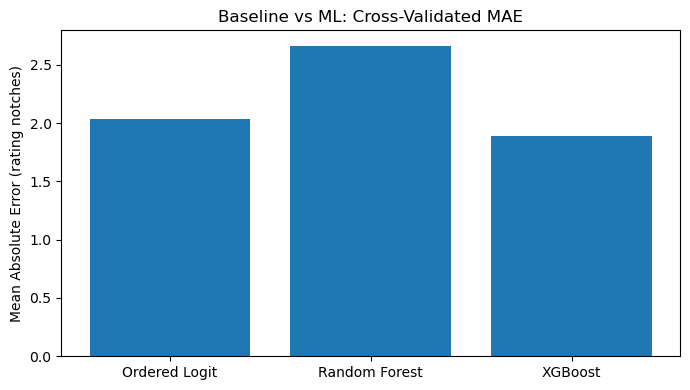

In [71]:
# bar chart comparing MAE across the three models
def plot_mae_comparison(comparison_df):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(comparison_df['Model'], comparison_df['MAE'])
    ax.set_ylabel('Mean Absolute Error (rating notches)')
    ax.set_title('Baseline vs ML: Cross-Validated MAE')
    plt.tight_layout()
    return ax

plot_mae_comparison(comparison)
plt.show()

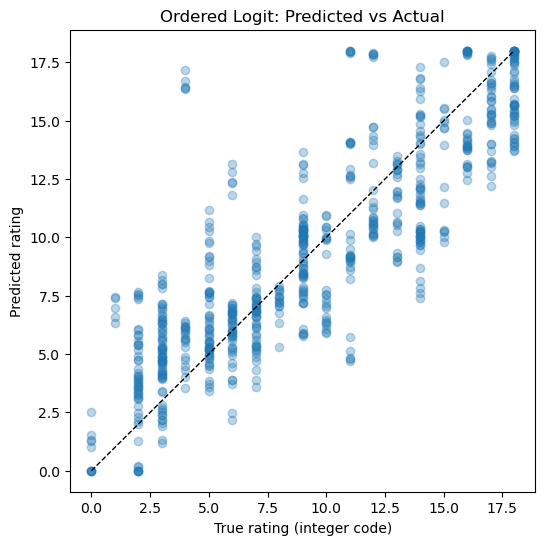

In [72]:
# predicted vs actual for the ordered logit baseline
def plot_pred_vs_actual(preds_df, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(preds_df['true_rating'], preds_df['pred_rating'], alpha=0.3)
    ax.plot([0, 18], [0, 18], 'k--', linewidth=1)
    ax.set_xlabel('True rating (integer code)')
    ax.set_ylabel('Predicted rating')
    ax.set_title(title)
    return ax

plot_pred_vs_actual(ordered_logit, 'Ordered Logit: Predicted vs Actual')
plt.show()

## Ordered Logit Coefficient Table

In [75]:
# build the standardized full-sample feature matrix used for the coefficient fit
def prepare_full_sample(df):
    X, y, _ = get_ol_features_target(df)
    X = drop_reference_outlook(X)
    X = X.fillna(X.mean())
    sd = X.std().replace(0, 1)
    return (X - X.mean()) / sd, y

In [76]:
# fit ordered logit on all data and return the statsmodels result
def fit_full_ordered_logit(df):
    X_full, y_full = prepare_full_sample(df)
    return fit_proportional_odds(X_full, y_full)

In [77]:
# print the coefficient table for the methods write-up
full_ol_result = fit_full_ordered_logit(ml_df.copy())
print(full_ol_result.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -297.18
Model:                   OrderedModel   AIC:                             656.4
Method:            Maximum Likelihood   BIC:                             747.8
Date:                Thu, 30 Apr 2026                                         
Time:                        13:19:26                                         
No. Observations:                 141                                         
Df Residuals:                     110                                         
Df Model:                          13                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
inflation_2022            -0.5469      0.502     -1.089      0.276      -1.531       0.437
inflation_2023  

In [78]:
gb_error = gradient_tree.groupby('country')['error'].mean().reset_index()
gb_error = gb_error.sort_values(by='error', ascending=False)

gb_error.head(10)

,country,error
10,Bahrain,9.695348
17,Bolivia,7.146477
28,China,6.820286
30,Cook Islands,6.772633
111,San Marino,5.567086
9,Bahamas,4.622797
68,Jersey,4.365296
27,Chile,4.292346
87,Montenegro,4.128518
124,Switzerland,4.095614


In [79]:
# train full model once for feature importance
X = ml_df.drop(columns=['Country/Territory','Date','country_code','Rating', 'index'])
y = ml_df['Rating']

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    random_state=42
)

model.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance

,Feature,Importance
0,gdp_per_capita_ppp,0.561951
1,avg_sovereign_debt_4yr,0.164249
2,current_account,0.052208
3,inflation_2024,0.046632
4,inflation_2023,0.042280
5,unemployment_rate,0.034224
6,fiscal_balance,0.020334
7,inflation_2022,0.020193
8,gdp_growth,0.019112
9,Outlook_Stable,0.016990


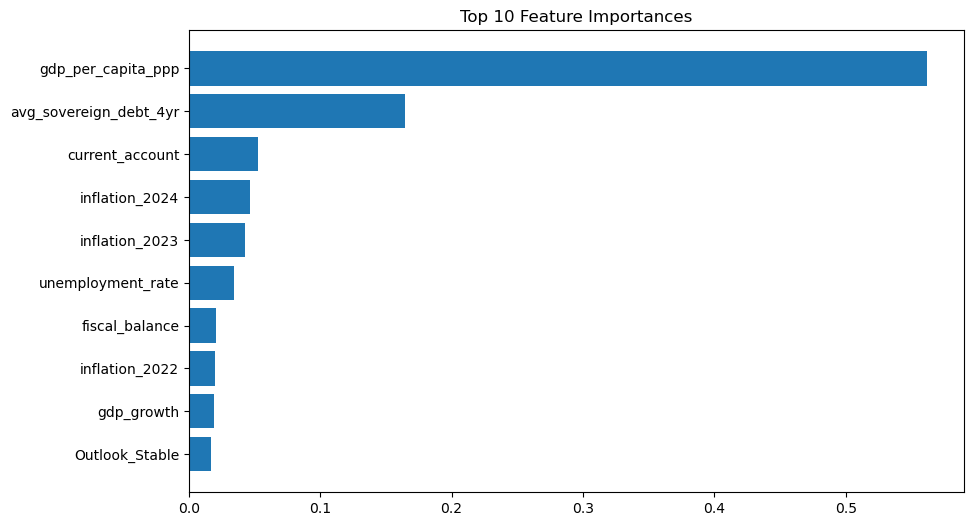

In [80]:
# plot top 10 feature importances
plt.figure(figsize=(10,6))
plt.barh(importance['Feature'].head(10), importance['Importance'].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()